In [1]:
import numpy as np
import tensorflow as tf

from tensorflow.keras.models import load_model, Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import GlobalAveragePooling2D
from sklearn.metrics import classification_report
from sklearn.utils.class_weight import compute_class_weight

D:\Anaconda\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [2]:
X_train = np.load("D:/PomegranateGuard/dataset/X_train.npy")
X_val   = np.load("D:/PomegranateGuard/dataset/X_val.npy")
X_test  = np.load("D:/PomegranateGuard/dataset/X_test.npy")

y_train = np.load("D:/PomegranateGuard/dataset/y_train.npy")
y_val   = np.load("D:/PomegranateGuard/dataset/y_val.npy")
y_test  = np.load("D:/PomegranateGuard/dataset/y_test.npy")

print("Dataset Loaded")

Dataset Loaded


In [3]:
encoder = load_model(
    "D:/PomegranateGuard/model/encoder_model.h5",
    compile=False
)

# Allow partial fine tuning
for layer in encoder.layers[:-10]:
    layer.trainable = False

for layer in encoder.layers[-10:]:
    layer.trainable = True

encoded_output = encoder.output

In [4]:
x = Conv2D(64, (3,3), activation='relu', padding='same', name="hybrid_conv1")(encoded_output)
x = BatchNormalization(name="hybrid_bn1")(x)
x = MaxPooling2D((2,2), name="hybrid_pool1")(x)

x = Conv2D(128, (3,3), activation='relu', padding='same', name="hybrid_conv2")(x)
x = BatchNormalization(name="hybrid_bn2")(x)
x = MaxPooling2D((2,2), name="hybrid_pool2")(x)

x = Flatten(name="hybrid_flatten")(x)

x = Dense(256, activation='relu', name="hybrid_dense1")(x)
x = Dropout(0.5, name="hybrid_dropout1")(x)

x = Dense(128, activation='relu', name="hybrid_dense2")(x)
x = Dropout(0.3, name="hybrid_dropout2")(x)

output = Dense(4, activation='softmax', name="hybrid_output")(x)

In [6]:
hybrid_model = Model(
    inputs=encoder.input,
    outputs=output
)

hybrid_model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

hybrid_model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape          ┃      Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)      │ (None, 224, 224, 3)   │            0 │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ conv2d (Conv2D)               │ (None, 224, 224, 32)  │          896 │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ max_pooling2d (MaxPooling2D)  │ (None, 112, 112, 32)  │            0 │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ conv2d_1 (Conv2D)             │ (None, 112, 112, 64)  │       18,496 │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ max_pooling2d_1               │ (None, 56, 56, 64)    │            0 │
│ (MaxPooling2D)                │                       │              │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ conv2d_2 (Conv2D)             │ (None, 56, 56, 128)   │       73,856 │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ max_pooling2d_2               │ (None, 28, 28, 128)   │            0 │
│ (MaxPooling2D)                │                       │              │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ hybrid_conv1 (Conv2D)         │ (None, 28, 28, 64)    │       73,792 │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ hybrid_bn1                    │ (None, 28, 28, 64)    │          256 │
│ (BatchNormalization)          │                       │              │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ hybrid_pool1 (MaxPooling2D)   │ (None, 14, 14, 64)    │            0 │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ hybrid_conv2 (Conv2D)         │ (None, 14, 14, 128)   │       73,856 │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ hybrid_bn2                    │ (None, 14, 14, 128)   │          512 │
│ (BatchNormalization)          │                       │              │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ hybrid_pool2 (MaxPooling2D)   │ (None, 7, 7, 128)     │            0 │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ hybrid_flatten (Flatten)      │ (None, 6272)          │            0 │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ hybrid_dense1 (Dense)         │ (None, 256)           │    1,605,888 │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ hybrid_dropout1 (Dropout)     │ (None, 256)           │            0 │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ hybrid_dense2 (Dense)         │ (None, 128)           │       32,896 │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ hybrid_dropout2 (Dropout)     │ (None, 128)           │            0 │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ hybrid_output (Dense)         │ (None, 4)             │          516 │
└───────────────────────────────┴───────────────────────┴──────────────┘

 Total params: 1,880,964 (7.18 MB)

 Trainable params: 1,880,580 (7.17 MB)

 Non-trainable params: 384 (1.50 KB)

In [7]:
X_test = np.load("D:/PomegranateGuard/dataset/X_test.npy")

X_test_encoded = encoder.predict(X_test)

np.save("D:/PomegranateGuard/dataset/X_test_autoencoder.npy", X_test_encoded)

X_test = np.load("D:/PomegranateGuard/dataset/X_test.npy")
y_test = np.load("D:/PomegranateGuard/dataset/y_test.npy")

print("Test dataset loaded:", X_test.shape)
#y_pred_probs = hybrid_model.predict(X_test)
#y_pred = np.argmax(y_pred_probs, axis=1)
print(hybrid_model.predict(X_train[:5]))

27/27 ━━━━━━━━━━━━━━━━━━━━ 4s 150ms/step
Test dataset loaded: (844, 224, 224, 3)
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 674ms/step
[[0.10824873 0.09536961 0.36332855 0.43305314]
 [0.13231987 0.09137426 0.44215617 0.33414963]
 [0.09796441 0.09789545 0.39854023 0.4055999 ]
 [0.13099836 0.20428778 0.4028013  0.26191252]
 [0.10221288 0.11014707 0.49234873 0.29529133]]


In [8]:
history = hybrid_model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=16,
    validation_data=(X_val, y_val),
)

Epoch 1/20
247/247 ━━━━━━━━━━━━━━━━━━━━ 161s 603ms/step - accuracy: 0.5168 - loss: 1.2104 - val_accuracy: 0.7097 - val_loss: 0.8426
Epoch 2/20
247/247 ━━━━━━━━━━━━━━━━━━━━ 145s 589ms/step - accuracy: 0.6882 - loss: 0.7716 - val_accuracy: 0.3566 - val_loss: 2.1490
Epoch 3/20
247/247 ━━━━━━━━━━━━━━━━━━━━ 145s 587ms/step - accuracy: 0.7996 - loss: 0.5469 - val_accuracy: 0.7038 - val_loss: 0.7957
Epoch 4/20
247/247 ━━━━━━━━━━━━━━━━━━━━ 139s 561ms/step - accuracy: 0.8751 - loss: 0.3619 - val_accuracy: 0.6114 - val_loss: 1.3829
Epoch 5/20
247/247 ━━━━━━━━━━━━━━━━━━━━ 144s 583ms/step - accuracy: 0.9248 - loss: 0.2250 - val_accuracy: 0.5652 - val_loss: 1.9354
Epoch 6/20
247/247 ━━━━━━━━━━━━━━━━━━━━ 149s 604ms/step - accuracy: 0.9406 - loss: 0.1821 - val_accuracy: 0.9455 - val_loss: 0.1556
Epoch 7/20
247/247 ━━━━━━━━━━━━━━━━━━━━ 146s 589ms/step - accuracy: 0.9472 - loss: 0.1581 - val_accuracy: 0.9585 - val_loss: 0.1162
Epoch 8/20
247/247 ━━━━━━━━━━━━━━━━━━━━ 157s 634ms/step - accuracy: 0.9617 -

In [9]:
hybrid_model.save("D:/PomegranateGuard/model/hybrid_model.h5")

print("Hybrid Model Saved")

Hybrid Model Saved


In [10]:
y_pred_probs = hybrid_model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

27/27 ━━━━━━━━━━━━━━━━━━━━ 5s 166ms/step


In [11]:
print("\nHybrid Model Classification Report:\n")

print(classification_report(
    y_test,
    y_pred,
    target_names=[
        "Healthy",
        "Bacterial Blight",
        "Anthracnose",
        "Fruit Rot"
    ]
))


Hybrid Model Classification Report:

                  precision    recall  f1-score   support

         Healthy       0.99      1.00      0.99       218
Bacterial Blight       0.97      0.94      0.96       150
     Anthracnose       1.00      0.99      0.99       175
       Fruit Rot       0.97      0.99      0.98       301

        accuracy                           0.98       844
       macro avg       0.98      0.98      0.98       844
    weighted avg       0.98      0.98      0.98       844



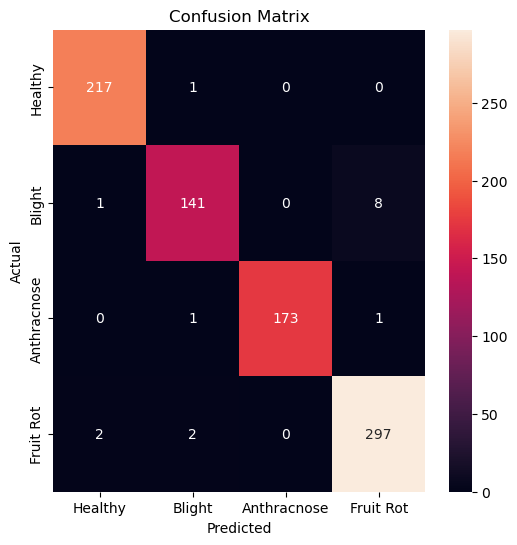

In [12]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,6))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=["Healthy","Blight","Anthracnose","Fruit Rot"],
            yticklabels=["Healthy","Blight","Anthracnose","Fruit Rot"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()